To demonstrate the Bias-Variance Tradeoff, we can visualize how model complexity affects error. High bias occurs when a model is too simple (underfitting), while high variance occurs when a model is overly complex (overfitting).

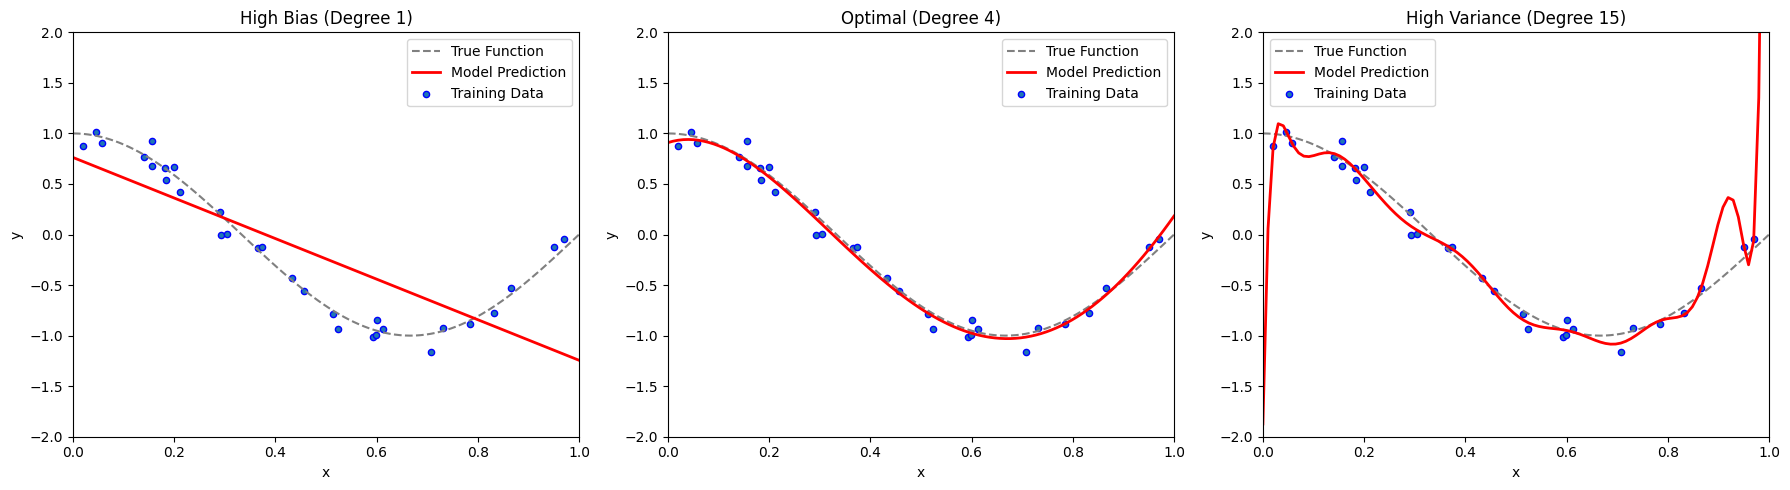

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Generate synthetic data
np.random.seed(42)
def true_function(X):
    return np.cos(1.5 * np.pi * X)

n_samples = 30
X = np.sort(np.random.rand(n_samples))
y = true_function(X) + np.random.randn(n_samples) * 0.1

# 2. Define degrees to represent different complexities
degrees = [1, 4, 15] # Underfit, Optimal, Overfit
titles = ["High Bias (Degree 1)", "Optimal (Degree 4)", "High Variance (Degree 15)"]

plt.figure(figsize=(18, 5))

for i, degree in enumerate(degrees):
    ax = plt.subplot(1, 3, i + 1)
    
    # Create and fit polynomial model
    polynomial_features = PolynomialFeatures(degree=degree, include_bias=False)
    linear_regression = LinearRegression()
    pipeline = make_pipeline(polynomial_features, linear_regression)
    pipeline.fit(X[:, np.newaxis], y)
    
    # Predict for plotting
    X_test = np.linspace(0, 1, 100)
    y_pred = pipeline.predict(X_test[:, np.newaxis])
    
    # Plotting
    plt.plot(X_test, true_function(X_test), label="True Function", color='gray', linestyle='--')
    plt.plot(X_test, y_pred, label="Model Prediction", color='red', linewidth=2)
    plt.scatter(X, y, edgecolor='b', s=20, label="Training Data")
    
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")
    plt.title(titles[i])

plt.tight_layout()
plt.show()

### Understanding the Tradeoff

| State | Complexity | Bias | Variance | Error Source |
| :--- | :--- | :--- | :--- | :--- |
| **Underfitting** | Low | **High** | Low | Model is too simple to capture the underlying trend (e.g., fitting a straight line to a curve). |
| **Overfitting** | High | Low | **High** | Model is too complex and captures the random noise in the training data. |
| **Optimal** | Medium | Low | Low | The "Sweet Spot" where the model generalizes well to new, unseen data. |

### The Mathematical Decomposition
In supervised learning, the total expected error of a model can be broken down into three components:

$$Total Error = Bias^2 + Variance + Irreducible Error$$

* **Bias:** Error from erroneous assumptions in the learning algorithm.
* **Variance:** Error from sensitivity to small fluctuations in the training set.
* **Irreducible Error ($\epsilon$):** The noise inherent in the data itself that no model can eliminate.

---

For the visualizations and the tradeoff analysis, a **synthetic non-linear dataset** has been used. In machine learning, synthetic data is often used to demonstrate these concepts because we know the "ground truth" (the true underlying pattern) and can control the amount of "noise" added.

The dataset used in the code follows these specific characteristics:

### 1. The True Signal (Ground Truth)
The core of the data is based on a **Sine wave** (or Cosine wave in the first example). This represents the actual physical or mathematical relationship we want the model to learn.
* **Formula:** $f(x) = \sin(1.5\pi x)$
* **Purpose:** This provides a non-linear target. A simple linear model ($y = mx + b$) cannot perfectly fit a curve, which allows us to visualize **Bias**.

### 2. The Noise (Irreducible Error)
Real-world data is never perfect; it contains "noise" from measurement errors or unobserved variables. I added **Gaussian (Normal) Noise** to the true signal.
* **Formula:** $y = f(x) + \epsilon$, where $\epsilon \sim \mathcal{N}(0, \sigma^2)$
* **Standard Deviation ($\sigma$):** Usually set between **0.1 and 0.3**. 
* **Purpose:** This creates the "Irreducible Error." It forces the model to decide whether a data point is part of the trend or just a random fluctuation. High-variance models mistake this noise for the signal.

### 3. Training vs. Testing Split
* **Training Set:** Usually small (approx. **20–30 samples**). Small datasets make the Bias-Variance tradeoff more obvious because the model has less evidence to "average out" the noise.
* **Test Set:** A dense grid of **100–200 points** across the same range. This is used to calculate the "Total Error" and see how well the model generalizes to points it never saw during training.

| Component | Mathematical Representation | Role in the Tradeoff |
| :--- | :--- | :--- |
| **Input ($X$)** | Random values between 0 and 1 (or $2\pi$) | The independent feature used for prediction. |
| **Signal ($f(x)$)** | $\sin(1.5\pi x)$ | The "True" relationship. Missing this causes **Bias**. |
| **Noise ($\epsilon$)** | $\mathcal{N}(0, \sigma^2)$ | Random fluctuations. Overfitting this causes **Variance**. |
| **Observed ($y$)** | $f(x) + \epsilon$ | What the model actually sees during training. |


By using this controlled environment, we can see exactly why a **Degree 1** model fails (it can't curve) and why a **Degree 15** model fails (it "jitters" to hit every noisy data point).

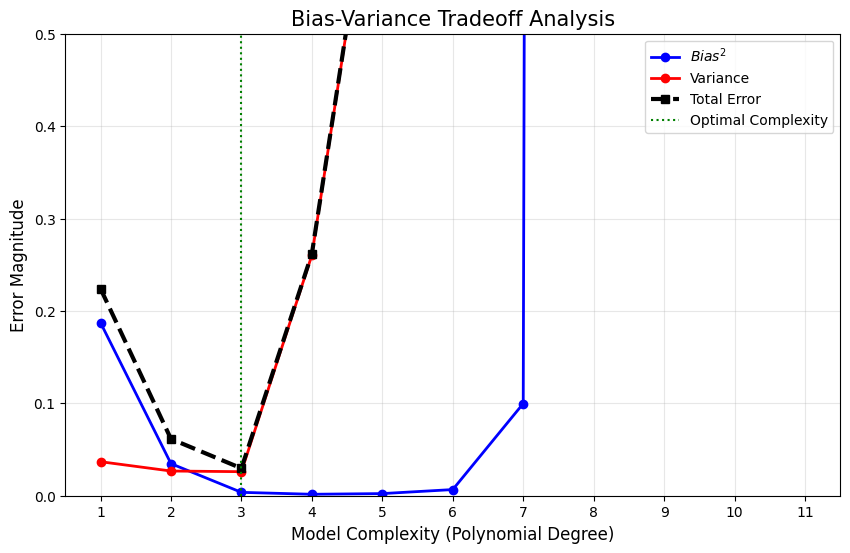

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. Setup True Function and Data
np.random.seed(42)
def true_func(x):
    return np.sin(1.5 * np.pi * x)

X_test = np.linspace(0, 1, 100).reshape(-1, 1)
y_test = true_func(X_test).flatten()

# 2. Experiment settings
n_samples = 20
n_trials = 100
degrees = np.arange(1, 12)

bias_sq_results = []
variance_results = []
total_error_results = []

# 3. Calculate Error Components for each Degree
for degree in degrees:
    all_preds = np.zeros((n_trials, 100))
    
    for i in range(n_trials):
        # Generate new noisy training data for each trial
        X_train = np.sort(np.random.rand(n_samples, 1), axis=0)
        y_train = true_func(X_train).flatten() + np.random.normal(0, 0.3, n_samples)
        
        # Fit model and predict
        model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
        model.fit(X_train, y_train)
        all_preds[i, :] = model.predict(X_test)
    
    # Calculate Bias^2: (Average Prediction - True Value)^2
    avg_pred = np.mean(all_preds, axis=0)
    bias_sq = np.mean((avg_pred - y_test) ** 2)
    
    # Calculate Variance: Average of (Prediction - Average Prediction)^2
    variance = np.mean(np.var(all_preds, axis=0))
    
    # Total Error: Mean Squared Error on the Test Set
    total_err = np.mean((all_preds - y_test) ** 2)
    
    bias_sq_results.append(bias_sq)
    variance_results.append(variance)
    total_error_results.append(total_err)

# 4. Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(degrees, bias_sq_results, label=r'$Bias^2$', color='blue', marker='o', lw=2)
plt.plot(degrees, variance_results, label='Variance', color='red', marker='o', lw=2)
plt.plot(degrees, total_error_results, label='Total Error', color='black', marker='s', lw=3, linestyle='--')

# Highlight the "Sweet Spot" (where Total Error is minimized)
plt.axvline(degrees[np.argmin(total_error_results)], color='green', linestyle=':', label='Optimal Complexity')

plt.title("Bias-Variance Tradeoff Analysis", fontsize=15)
plt.xlabel("Model Complexity (Polynomial Degree)", fontsize=12)
plt.ylabel("Error Magnitude", fontsize=12)
plt.xticks(degrees)
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 0.5) # Limiting Y-axis for clarity as variance can explode
plt.show()